In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import os

# --- 1. MODEL 2 COMPONENTS ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    dist_from_center = np.sqrt((x - center)**2 + (y - center)**2)
    mask_array = (dist_from_center <= radius).astype(np.float32)
    mask_array = mask_array[:, :, np.newaxis]
    mask_tensor = tf.constant(mask_array, dtype=image.dtype)
    return image * mask_tensor

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. THE SSL ARCHITECTURE ---
def build_biomarker_ssl_hvit(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), output_shape=input_shape)(inputs)
    
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    x = base_model(x)
    
    f_h, f_w, channels = x.shape[1], x.shape[2], x.shape[3]
    num_patches = f_h * f_w
    x = layers.Reshape((num_patches, channels))(x)
    
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    x = layers.Add()([res, x])
    
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

# --- 3. THE FIX: Correct Batch Data Preparation ---
def prepare_ssl_batch(images):
    # Normalize images
    images = tf.cast(images, tf.float32) / 255.0
    
    # Process each image in the batch individually to give each its own rotation
    def rotate_single_image(img):
        num_rotations = tf.random.uniform([], 0, 4, dtype=tf.int32)
        rotated_img = tf.image.rot90(img, k=num_rotations)
        return rotated_img, num_rotations

    # Use map_fn to apply rotation and create a label for every image in the 32-batch
    rotated_images, labels = tf.map_fn(
        rotate_single_image, 
        images, 
        fn_output_signature=(tf.float32, tf.int32)
    )
    return rotated_images, labels

print("🚀 Loading 10,000 sharpened images...")
full_ssl_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/ssl-final-sharpen-dataset",
    label_mode=None,
    image_size=(300, 300),
    batch_size=32,
    shuffle=True
).map(prepare_ssl_batch).prefetch(tf.data.AUTOTUNE)

ssl_model = build_biomarker_ssl_hvit()
ssl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("🚀 Starting SSL Phase 1 training (Each image gets its own rotation)...")
ssl_model.fit(full_ssl_ds, epochs=15)

ssl_model.save_weights("biomarker_anatomy_expert.weights.h5")
print("\n✅ Expert weights saved successfully!")

🚀 Loading 10,000 sharpened images...
Found 9870 files.
🚀 Starting SSL Phase 1 training (Each image gets its own rotation)...
Epoch 1/15


I0000 00:00:1769361076.999210     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-25 17:11:27.639328: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:11:27.789664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:11:29.171900: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:11:29.312807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investiga

308/309 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7609 - loss: 0.5373

2026-01-25 17:13:26.635670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:13:26.776153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:13:28.093058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:13:28.232913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:13:29.211620: E external/local_xla/xla/stream_

309/309 ━━━━━━━━━━━━━━━━━━━━ 213s 373ms/step - accuracy: 0.7617 - loss: 0.5356
Epoch 2/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 221ms/step - accuracy: 0.9706 - loss: 0.0773
Epoch 3/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 68s 221ms/step - accuracy: 0.9786 - loss: 0.0573
Epoch 4/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9781 - loss: 0.0574
Epoch 5/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9875 - loss: 0.0355
Epoch 6/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 221ms/step - accuracy: 0.9861 - loss: 0.0361
Epoch 7/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9862 - loss: 0.0364
Epoch 8/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 68s 221ms/step - accuracy: 0.9881 - loss: 0.0285
Epoch 9/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9866 - loss: 0.0338
Epoch 10/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 68s 221ms/step - accuracy: 0.9908 - loss: 0.0256
Epoch 11/15
309/309 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.9894 - loss: 0.0285
Epoch 12/15
309/309 ━━━━━━━━━

✅ Found 9870 total images.
✅ Visualizing: ASD Data_Train_tipical_0141_R.jpg


2026-01-25 17:37:02.871467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:37:03.028417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 17:37:03.163113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


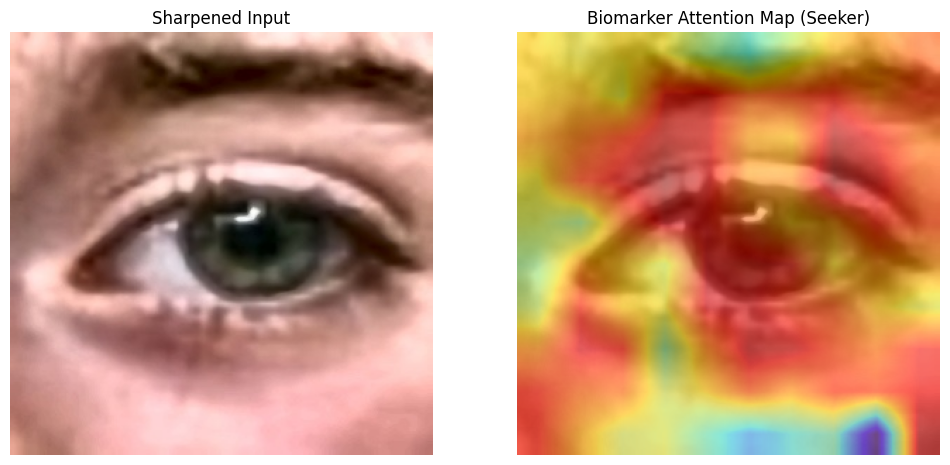

In [10]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

def visualize_seeker_attention(model, img_path):
    # 1. Prepare the image
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"❌ Error: Could not find image at {img_path}")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (300, 300))
    img_tensor = np.expand_dims(img_resized / 255.0, axis=0)
    
    # 2. Extract the output of the 'seeker_layer'
    # Use the name we defined in our class: "seeker_layer"
    seeker_model = models.Model(inputs=model.input, outputs=model.get_layer("seeker_layer").output)
    attention_output = seeker_model.predict(img_tensor) 
    
    # 3. Create the Heatmap
    # Average across the channels to see the most 'important' parts
    heatmap = np.mean(attention_output[0], axis=-1)
    
    # Reshape back to grid (EfficientNetB0 usually 10x10 at this size)
    grid_size = int(np.sqrt(heatmap.shape[0])) 
    heatmap = heatmap.reshape((grid_size, grid_size))
    
    # 4. Upscale for Overlay
    heatmap_resized = cv2.resize(heatmap, (300, 300))
    heatmap_norm = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Sharpened Input")
    plt.imshow(img_resized)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Biomarker Attention Map (Seeker)")
    plt.imshow(img_resized)
    plt.imshow(heatmap_norm, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

# --- AUTO-FIND A REAL IMAGE (FIXED) ---
# We point to the main input folder
general_folder = Path("/kaggle/input/ssl-final-sharpen-dataset")

# Use rglob('**/*.jpg') to search deep into all subfolders
real_images = list(general_folder.rglob("*.jpg"))

if len(real_images) > 0:
    print(f"✅ Found {len(real_images)} total images.")
    print(f"✅ Visualizing: {real_images[0].name}")
    visualize_seeker_attention(ssl_model, real_images[0])
else:
    # If this still fails, let's print the folder content to see what's wrong
    print(f"❌ Still no images found in {general_folder}")
    print("Available folders in input:")
    print(os.listdir("/kaggle/input/ssl-final-sharpen-dataset"))

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import os

# --- 1. MODEL 2 COMPONENTS (Kept Exactly the Same) ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    dist_from_center = np.sqrt((x - center)**2 + (y - center)**2)
    mask_array = (dist_from_center <= radius).astype(np.float32)
    mask_array = mask_array[:, :, np.newaxis]
    mask_tensor = tf.constant(mask_array, dtype=image.dtype)
    return image * mask_tensor

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. THE DUAL-TASK ARCHITECTURE ---
def build_hybrid_ssl_hvit(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)
    
    # Pre-processing
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), output_shape=input_shape)(inputs)
    
    # Backbone
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    features = base_model(x)
    
    # Feature Map Info for MAE Decoder
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    # Transformer Path
    x = layers.Reshape((num_patches, channels))(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    encoded = layers.Add()([res, x])
    
    # TASK A: ROTATION HEAD (Global Understanding)
    rot_x = layers.GlobalAveragePooling1D()(encoded)
    rotation_output = layers.Dense(4, activation='softmax', name="rotation_output")(rot_x)
    
    # TASK B: MAE DECODER HEAD (Internal Texture Reconstruction)
    # We take the encoded features and try to 're-draw' the original eye pixels
    mae_x = layers.Reshape((f_h, f_w, channels))(encoded)
    mae_x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    # Upscale back to original 300x300 size
    mae_x = layers.UpSampling2D(size=(2, 2))(mae_x) # Adjusted for EfficientNet output ratio
    mae_x = layers.Resizing(300, 300)(mae_x)
    reconstruction_output = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae_x)
    
    return models.Model(inputs, [reconstruction_output, rotation_output])

# --- 3. HYBRID DATA PREPARATION (Masking + Rotating) ---
def prepare_hybrid_batch(images):
    images = tf.cast(images, tf.float32) / 255.0
    
    def hybrid_logic(img):
        # A. Rotation logic
        num_rotations = tf.random.uniform([], 0, 4, dtype=tf.int32)
        
        # B. MAE Masking logic (Hiding 50% of patches)
        # We create a 10x10 grid of blocks and randomly black them out
        mask = tf.cast(tf.random.uniform([10, 10, 1]) > 0.5, tf.float32)
        mask = tf.image.resize(mask, [300, 300], method='nearest')
        masked_img = img * mask
        
        # Apply rotation to the masked image
        final_input = tf.image.rot90(masked_img, k=num_rotations)
        
        # Return Input and two labels: (Original_Image for MAE, Rotation_Index)
        return final_input, (img, num_rotations)

    return tf.map_fn(hybrid_logic, images, fn_output_signature=(tf.float32, (tf.float32, tf.int32)))

# --- 4. EXECUTION ---
print("🚀 Preparing Hybrid (Rotation + MAE) Dataset...")
full_ssl_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/ssl-final-sharpen-dataset",
    label_mode=None,
    image_size=(300, 300),
    batch_size=16, # Reduced batch size slightly for Dual-Task memory
    shuffle=True
).map(prepare_hybrid_batch).prefetch(tf.data.AUTOTUNE)

model = build_hybrid_ssl_hvit()

# Loss Weights: We prioritize MAE (Reconstruction) as the harder task
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={'mae_output': 'mse', 'rotation_output': 'sparse_categorical_crossentropy'},
    loss_weights={'mae_output': 1.0, 'rotation_output': 0.5},
    metrics={'rotation_output': 'accuracy'}
)

print("🚀 Starting Hybrid SSL Phase 1...")
model.fit(full_ssl_ds, epochs=25)

model.save_weights("hybrid_anatomy_expert.weights.h5")
print("\n✅ Multi-task weights saved!")

2026-01-25 19:10:28.132796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769368228.298467      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769368228.351128      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769368228.761337      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769368228.761375      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769368228.761378      55 computation_placer.cc:177] computation placer alr

🚀 Preparing Hybrid (Rotation + MAE) Dataset...
Found 9870 files.


I0000 00:00:1769368269.560713      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769368269.564582      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting Hybrid SSL Phase 1...
Epoch 1/25


I0000 00:00:1769368312.447110     133 service.cc:152] XLA service 0x7804a4016af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769368312.447152     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769368312.447157     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769368319.382896     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-25 19:12:08.996682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:12:09.138255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:12:10.361159: E external/local_xl

616/617 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 0.4334 - mae_output_loss: 0.0488 - rotation_output_accuracy: 0.6442 - rotation_output_loss: 0.7690

2026-01-25 19:15:08.931911: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:15:09.071913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:15:10.296296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:15:10.436149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 19:15:13.760776: E external/local_xla/xla/stream_

617/617 ━━━━━━━━━━━━━━━━━━━━ 275s 289ms/step - loss: 0.4328 - mae_output_loss: 0.0488 - rotation_output_accuracy: 0.6448 - rotation_output_loss: 0.7680
Epoch 2/25
617/617 ━━━━━━━━━━━━━━━━━━━━ 129s 208ms/step - loss: 0.1150 - mae_output_loss: 0.0376 - rotation_output_accuracy: 0.9459 - rotation_output_loss: 0.1548
Epoch 3/25
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 207ms/step - loss: 0.0791 - mae_output_loss: 0.0344 - rotation_output_accuracy: 0.9667 - rotation_output_loss: 0.0894
Epoch 4/25
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 207ms/step - loss: 0.0727 - mae_output_loss: 0.0320 - rotation_output_accuracy: 0.9704 - rotation_output_loss: 0.0813
Epoch 5/25
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 207ms/step - loss: 0.0665 - mae_output_loss: 0.0306 - rotation_output_accuracy: 0.9740 - rotation_output_loss: 0.0717
Epoch 6/25
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 207ms/step - loss: 0.0592 - mae_output_loss: 0.0297 - rotation_output_accuracy: 0.9757 - rotation_output_loss: 0.0589
Epoch 7/25
617/617 ━━━━━━━━━━━━━━

✅ Found 9870 total images.
✅ Visualizing: ASD Data_Train_tipical_0141_R.jpg


2026-01-25 20:09:52.355697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-25 20:09:52.491667: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


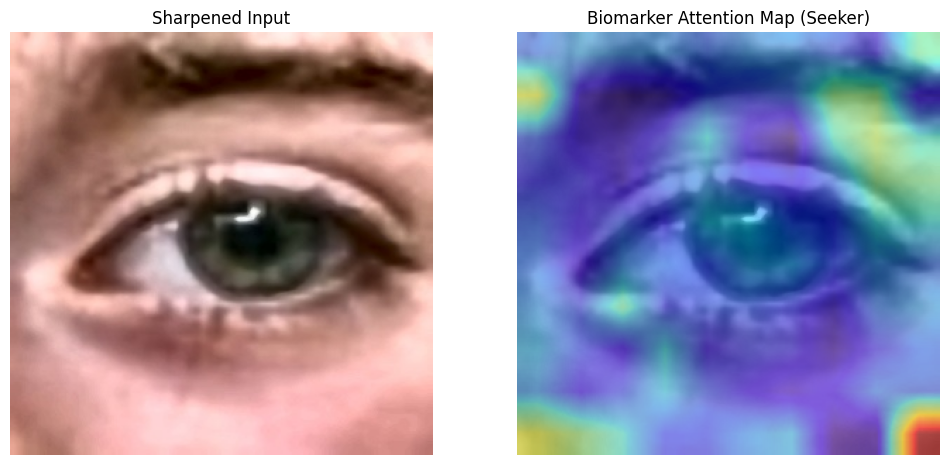

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

def visualize_seeker_attention(model, img_path):
    # 1. Prepare the image
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"❌ Error: Could not find image at {img_path}")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (300, 300))
    img_tensor = np.expand_dims(img_resized / 255.0, axis=0)
    
    # 2. Extract the output of the 'seeker_layer'
    # Use the name we defined in our class: "seeker_layer"
    seeker_model = models.Model(inputs=model.input, outputs=model.get_layer("seeker_layer").output)
    attention_output = seeker_model.predict(img_tensor) 
    
    # 3. Create the Heatmap
    # Average across the channels to see the most 'important' parts
    heatmap = np.mean(attention_output[0], axis=-1)
    
    # Reshape back to grid (EfficientNetB0 usually 10x10 at this size)
    grid_size = int(np.sqrt(heatmap.shape[0])) 
    heatmap = heatmap.reshape((grid_size, grid_size))
    
    # 4. Upscale for Overlay
    heatmap_resized = cv2.resize(heatmap, (300, 300))
    heatmap_norm = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Sharpened Input")
    plt.imshow(img_resized)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Biomarker Attention Map (Seeker)")
    plt.imshow(img_resized)
    plt.imshow(heatmap_norm, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

# --- AUTO-FIND A REAL IMAGE (FIXED) ---
# We point to the main input folder
general_folder = Path("/kaggle/input/ssl-final-sharpen-dataset")

# Use rglob('**/*.jpg') to search deep into all subfolders
real_images = list(general_folder.rglob("*.jpg"))

if len(real_images) > 0:
    print(f"✅ Found {len(real_images)} total images.")
    print(f"✅ Visualizing: {real_images[0].name}")
    visualize_seeker_attention(model, real_images[0])
else:
    # If this still fails, let's print the folder content to see what's wrong
    print(f"❌ Still no images found in {general_folder}")
    print("Available folders in input:")
    print(os.listdir("/kaggle/input/ssl-final-sharpen-dataset"))

Fast testing


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import os

# --- 1. MODEL 2 COMPONENTS ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs) # Fixed Naming
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="positional_embedding", **kwargs) # Fixed Naming
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. ARCHITECTURE ---
def build_hybrid_ssl_hvit(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), output_shape=input_shape)(inputs)
    
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    x = layers.Reshape((num_patches, channels))(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    encoded = layers.Add()([res, x])
    
    # Heads
    rot_x = layers.GlobalAveragePooling1D()(encoded)
    rotation_output = layers.Dense(4, activation='softmax', name="rotation_output")(rot_x)
    
    mae_x = layers.Reshape((f_h, f_w, channels))(encoded)
    mae_x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.UpSampling2D(size=(2, 2))(mae_x)
    mae_x = layers.Resizing(300, 300)(mae_x)
    reconstruction_output = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae_x)
    
    return models.Model(inputs, [reconstruction_output, rotation_output])

# --- 3. HYBRID DATA PREPARATION (Masking + Rotating) ---
def prepare_hybrid_batch(images):
    images = tf.cast(images, tf.float32) / 255.0
    
    def hybrid_logic(img):
        # A. Rotation logic
        num_rotations = tf.random.uniform([], 0, 4, dtype=tf.int32)
        
        # B. MAE Masking logic (Hiding 50% of patches)
        # We create a 10x10 grid of blocks and randomly black them out
        mask = tf.cast(tf.random.uniform([10, 10, 1]) > 0.5, tf.float32)
        mask = tf.image.resize(mask, [300, 300], method='nearest')
        masked_img = img * mask
        
        # Apply rotation to the masked image
        final_input = tf.image.rot90(masked_img, k=num_rotations)
        
        # Return Input and two labels: (Original_Image for MAE, Rotation_Index)
        return final_input, (img, num_rotations)

    return tf.map_fn(hybrid_logic, images, fn_output_signature=(tf.float32, (tf.float32, tf.int32)))

# --- 4. EXECUTION ---
print("🚀 Preparing Hybrid (Rotation + MAE) Dataset...")
full_ssl_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/ssl-final-sharpen-dataset",
    label_mode=None,
    image_size=(300, 300),
    batch_size=16, # Reduced batch size slightly for Dual-Task memory
    shuffle=True
).map(prepare_hybrid_batch).prefetch(tf.data.AUTOTUNE)

model = build_hybrid_ssl_hvit()

# Loss Weights: We prioritize MAE (Reconstruction) as the harder task
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={'mae_output': 'mse', 'rotation_output': 'sparse_categorical_crossentropy'},
    loss_weights={'mae_output': 1.0, 'rotation_output': 0.5},
    metrics={'rotation_output': 'accuracy'}
)

print("🚀 Starting Hybrid SSL Phase 1...")
model.fit(full_ssl_ds, epochs=15)

model.save_weights("hybrid_anatomy_expert.weights.h5")
print("\n✅ Multi-task weights saved!")

🚀 Preparing Hybrid (Rotation + MAE) Dataset...
Found 9870 files.
🚀 Starting Hybrid SSL Phase 1...
Epoch 1/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 244s 268ms/step - loss: 0.4287 - mae_output_loss: 0.0482 - rotation_output_accuracy: 0.6472 - rotation_output_loss: 0.7609
Epoch 2/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 129s 208ms/step - loss: 0.1018 - mae_output_loss: 0.0378 - rotation_output_accuracy: 0.9500 - rotation_output_loss: 0.1279
Epoch 3/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 207ms/step - loss: 0.0834 - mae_output_loss: 0.0345 - rotation_output_accuracy: 0.9633 - rotation_output_loss: 0.0978
Epoch 4/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 208ms/step - loss: 0.0660 - mae_output_loss: 0.0324 - rotation_output_accuracy: 0.9752 - rotation_output_loss: 0.0672
Epoch 5/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 208ms/step - loss: 0.0654 - mae_output_loss: 0.0310 - rotation_output_accuracy: 0.9724 - rotation_output_loss: 0.0687
Epoch 6/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 128s 207ms/step - loss: 0.0594 - mae_output_los

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import GroupKFold
import pandas as pd
import numpy as np
import os
from pathlib import Path

# --- 1. MODEL 2 COMPONENTS (Required to prevent NameError) ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    dist_from_center = np.sqrt((x - center)**2 + (y - center)**2)
    mask_array = (dist_from_center <= radius).astype(np.float32)
    mask_array = mask_array[:, :, np.newaxis]
    mask_tensor = tf.constant(mask_array, dtype=image.dtype)
    return image * mask_tensor

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. DATASET PREPARATION & SUBJECT EXTRACTION ---
severity_root = Path("/kaggle/input/ssl-final-sharpen-dataset/severity")
class_map = {'mild': 0, 'low': 1, 'medium': 2, 'high': 3}
data_list = []

for folder, label in class_map.items():
    folder_path = severity_root / folder
    for img_path in folder_path.glob("*.jpg"):
        # Extracts ID '1' from '1-100-high-le.jpg'
        subj_id = img_path.name.split('-')[0] 
        data_list.append({'path': str(img_path), 'label': label, 'subject': subj_id})

df = pd.DataFrame(data_list)
print(f"✅ Found {len(df)} images from {df['subject'].nunique()} unique subjects.")

# --- 3. HELPER FUNCTIONS ---
def get_dataset(paths, labels, batch_size=16, shuffle=True):
    def parse_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        return tf.cast(img, tf.float32) / 255.0, label
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(100)
    return ds.map(parse_img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

def predict_with_tta(model, ds, tta_steps=10):
    all_preds = []
    for _ in range(tta_steps):
        preds = model.predict(ds, verbose=0)
        all_preds.append(preds)
    return np.mean(all_preds, axis=0)

# --- 4. ARCHITECTURE BUILD ---
def build_diagnostic_model():
    inputs = layers.Input(shape=(300, 300, 3))
    
    # Heavy Augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img))(x)
    
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(300, 300, 3))
    x = base_model(x)
    
    f_h, f_w, channels = x.shape[1], x.shape[2], x.shape[3]
    num_patches = f_h * f_w
    x = layers.Reshape((num_patches, channels))(x)
    x = SpatialAttention()(x) 
    x = PositionalEmbedding(num_patches, channels)(x) 
    
    res = x
    x = layers.LayerNormalization()(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.3)(x, x)
    x = layers.Add()([res, x])


    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    try:
        model.load_weights("/kaggle/working/hybrid_anatomy_expert.weights.h5", by_name=True, skip_mismatch=True)
        print("✅ SUCCESS: Hybrid SSL Weights Loaded.")
    except:
        print("⚠️ ERROR: Weights failed to load. Check file path.")
        
    return model

# --- 5. EXECUTION: 5-FOLD SUBJECT-WISE TWO-STAGE TRAINING ---
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(df.path, df.label, groups=df.subject)):
    print(f"\n🚀 STARTING FOLD {fold+1}")
    
    train_ds = get_dataset(df.iloc[train_idx].path, df.iloc[train_idx].label)
    val_ds = get_dataset(df.iloc[val_idx].path, df.iloc[val_idx].label, shuffle=False)
    
    model = build_diagnostic_model() 
    
    # STAGE 1: HEAD STABILIZATION
    print("⏳ Stage 1: Stabilizing Diagnostic Head (10 Epochs)...")
    for layer in model.layers:
        if 'efficientnet' in layer.name: layer.trainable = False
            
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=10)
    
    # STAGE 2: SURGICAL FINE-TUNING
    print("🔬 Stage 2: Unfreezing Last 50 Layers for Precision...")
    for layer in model.layers:
        if 'efficientnet' in layer.name:
            layer.trainable = True
            for sub_layer in layer.layers[:-50]: sub_layer.trainable = False
                
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=40, 
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
    
    # FINAL TTA EVALUATION
    final_val_preds = predict_with_tta(model, val_ds)
    val_acc = np.mean(np.argmax(final_val_preds, axis=1) == df.iloc[val_idx].label.values)
    print(f"🎯 Fold {fold+1} Final Accuracy (with TTA): {val_acc:.4f}")

✅ Found 4000 images from 40 unique subjects.

🚀 STARTING FOLD 1
⚠️ ERROR: Weights failed to load. Check file path.
⏳ Stage 1: Stabilizing Diagnostic Head (10 Epochs)...
Epoch 1/10


E0000 00:00:1769374114.951789      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.8787 - loss: 0.5978 - val_accuracy: 0.1250 - val_loss: 7.8725
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.7651 - loss: 1.1602 - val_accuracy: 0.1250 - val_loss: 8.2862
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.7814 - loss: 0.9624 - val_accuracy: 0.1250 - val_loss: 6.9670
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.7740 - loss: 0.9350 - val_accuracy: 0.1250 - val_loss: 6.5854
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.7787 - loss: 0.8884 - val_accuracy: 0.1250 - val_loss: 7.8582
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.7962 - loss: 0.8254 - val_accuracy: 0.1250 - val_loss: 7.7413
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.7727 - loss: 0.9580 - val_accuracy: 0.1250 - val_loss: 8.1812
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.7720 - loss: 0.9169 - val_accurac

E0000 00:00:1769374294.835854      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 116ms/step - accuracy: 0.5299 - loss: 1.0988 - val_accuracy: 0.1250 - val_loss: 6.0117
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.2566 - loss: 1.8519 - val_accuracy: 0.1250 - val_loss: 3.4818
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.1632 - loss: 1.6923 - val_accuracy: 0.1250 - val_loss: 2.2870
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.1606 - loss: 1.5090 - val_accuracy: 0.1250 - val_loss: 2.7578
Epoch 5/40
168/200 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.1416 - loss: 1.4805

KeyboardInterrupt: 

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import os

# --- 1. CORE MODEL 2 COMPONENTS ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        # EXPLICIT NAME FOR WEIGHT ALIGNMENT
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        # EXPLICIT NAME FOR WEIGHT ALIGNMENT
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. ARCHITECTURE BUILD ---
def build_hybrid_ssl_hvit(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), output_shape=input_shape)(inputs)
    
    # Backbone (EfficientNetV2B0)
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    # --- TRANSFORMER BLOCK START ---
    x = layers.Reshape((num_patches, channels))(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    # A. Multi-Head Attention Block
    res_attn = x
    x = layers.LayerNormalization(name="norm_attn")(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1, name="shared_mha")(x, x)
    x = layers.Add(name="add_attn")([res_attn, x])
    
    # B. THE MISSING FFN BLOCK (Added here for alignment)
    res_ffn = x
    x = layers.LayerNormalization(name="norm_ffn")(x)
    x = layers.Dense(channels * 2, activation='gelu', name="shared_ffn_expand")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(channels, name="shared_ffn_project")(x)
    x = layers.Add(name="add_ffn")([res_ffn, x])
    
    encoded = x
    # --- TRANSFORMER BLOCK END ---
    
    # TASK A: ROTATION HEAD
    rot_x = layers.GlobalAveragePooling1D(name="rot_gap")(encoded)
    rotation_output = layers.Dense(4, activation='softmax', name="rotation_output")(rot_x)
    
    # TASK B: MAE DECODER HEAD
    mae_x = layers.Reshape((f_h, f_w, channels))(encoded)
    mae_x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.UpSampling2D(size=(2, 2))(mae_x)
    mae_x = layers.Resizing(300, 300)(mae_x)
    reconstruction_output = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae_x)
    
    return models.Model(inputs, [reconstruction_output, rotation_output])



# --- 3. HYBRID DATA PREPARATION (Masking + Rotating) ---
def prepare_hybrid_batch(images):
    images = tf.cast(images, tf.float32) / 255.0
    
    def hybrid_logic(img):
        # A. Rotation logic
        num_rotations = tf.random.uniform([], 0, 4, dtype=tf.int32)
        
        # B. MAE Masking logic (Hiding 50% of patches)
        # We create a 10x10 grid of blocks and randomly black them out
        mask = tf.cast(tf.random.uniform([10, 10, 1]) > 0.5, tf.float32)
        mask = tf.image.resize(mask, [300, 300], method='nearest')
        masked_img = img * mask
        
        # Apply rotation to the masked image
        final_input = tf.image.rot90(masked_img, k=num_rotations)
        
        # Return Input and two labels: (Original_Image for MAE, Rotation_Index)
        return final_input, (img, num_rotations)

    return tf.map_fn(hybrid_logic, images, fn_output_signature=(tf.float32, (tf.float32, tf.int32)))

# --- 4. EXECUTION ---
print("🚀 Preparing Hybrid (Rotation + MAE) Dataset...")
full_ssl_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/ssl-final-sharpen-dataset",
    label_mode=None,
    image_size=(300, 300),
    batch_size=16, # Reduced batch size slightly for Dual-Task memory
    shuffle=True
).map(prepare_hybrid_batch).prefetch(tf.data.AUTOTUNE)

model = build_hybrid_ssl_hvit()

# Loss Weights: We prioritize MAE (Reconstruction) as the harder task
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={'mae_output': 'mse', 'rotation_output': 'sparse_categorical_crossentropy'},
    loss_weights={'mae_output': 1.0, 'rotation_output': 0.5},
    metrics={'rotation_output': 'accuracy'}
)

print("🚀 Starting Hybrid SSL Phase 1...")
model.fit(full_ssl_ds, epochs=1)

model.save_weights("hybrid_anatomy_expert_first.weights.h5")
print("\n✅ Multi-task weights saved!")

🚀 Preparing Hybrid (Rotation + MAE) Dataset...
Found 9870 files.
🚀 Starting Hybrid SSL Phase 1...
617/617 ━━━━━━━━━━━━━━━━━━━━ 262s 287ms/step - loss: 0.4459 - mae_output_loss: 0.0473 - rotation_output_accuracy: 0.6298 - rotation_output_loss: 0.7972

✅ Multi-task weights saved!


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import GroupKFold
import pandas as pd
import numpy as np
import os
from pathlib import Path

# --- 1. CORE COMPONENTS (Ensuring Names Match Phase 1) ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. DATASET PREPARATION (Defining 'df' here fixes your NameError) ---
severity_root = Path("/kaggle/input/ssl-final-sharpen-dataset/severity")
class_map = {'mild': 0, 'low': 1, 'medium': 2, 'high': 3}
data_list = []

for folder, label in class_map.items():
    folder_path = severity_root / folder
    for img_path in folder_path.glob("*.jpg"):
        subj_id = img_path.name.split('-')[0] # Extracting subject ID '1', '10', etc.
        data_list.append({'path': str(img_path), 'label': label, 'subject': subj_id})

df = pd.DataFrame(data_list)
print(f"✅ Found {len(df)} images from {df['subject'].nunique()} unique subjects.")

# --- 3. HELPER FUNCTIONS ---
def get_dataset(paths, labels, batch_size=16, shuffle=True):
    def parse_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        return tf.cast(img, tf.float32) / 255.0, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(100)
    return ds.map(parse_img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

def predict_with_tta(model, ds, tta_steps=10):
    all_preds = []
    for _ in range(tta_steps):
        preds = model.predict(ds, verbose=0)
        all_preds.append(preds)
    return np.mean(all_preds, axis=0)

# --- 4. ARCHITECTURE WITH FFN (Perfect Match for Phase 1) ---
def build_diagnostic_model():
    inputs = layers.Input(shape=(300, 300, 3))
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img))(x)
    
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(300, 300, 3))
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    x = layers.Reshape((num_patches, channels))(features)
    x = SpatialAttention()(x) 
    x = PositionalEmbedding(num_patches, channels)(x) 
    
    # A. Multi-Head Attention
    res_attn = x
    x = layers.LayerNormalization(name="norm_attn")(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.3, name="shared_mha")(x, x)
    x = layers.Add(name="add_attn")([res_attn, x])

    # B. FFN BLOCK
    res_ffn = x
    x = layers.LayerNormalization(name="norm_ffn")(x)
    x = layers.Dense(channels * 2, activation='gelu', name="shared_ffn_expand")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(channels, name="shared_ffn_project")(x)
    x = layers.Add(name="add_ffn")([res_ffn, x])
    
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    try:
        # Loading the .h2 file you saved in Phase 1
        model.load_weights("/kaggle/working/hybrid_anatomy_expert.weights.h5", by_name=True, skip_mismatch=True)
        print("✅ SUCCESS: Phase 1 Hybrid SSL Weights Loaded.")
    except:
        print("⚠️ ERROR: Weights failed to load. Check names.")
    return model

# --- 5. EXECUTION: 5-FOLD SUBJECT-WISE TWO-STAGE TRAINING ---
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(df.path, df.label, groups=df.subject)):
    print(f"\n🚀 STARTING FOLD {fold+1}")
    train_ds = get_dataset(df.iloc[train_idx].path, df.iloc[train_idx].label)
    val_ds = get_dataset(df.iloc[val_idx].path, df.iloc[val_idx].label, shuffle=False)
    model = build_diagnostic_model() 
    
    # STAGE 1: Head Stabilization (10 Epochs)
    for layer in model.layers:
        if 'efficientnet' in layer.name: layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=10)
    
    # STAGE 2: Surgical Fine-Tuning (40 Epochs)
    for layer in model.layers:
        if 'efficientnet' in layer.name:
            layer.trainable = True
            for sub_layer in layer.layers[:-50]: sub_layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=40, callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
    
    # FINAL TTA EVALUATION
    final_val_preds = predict_with_tta(model, val_ds)
    val_acc = np.mean(np.argmax(final_val_preds, axis=1) == df.iloc[val_idx].label.values)
    print(f"🎯 Fold {fold+1} Final Accuracy (with TTA): {val_acc:.4f}")

✅ Found 4000 images from 40 unique subjects.

🚀 STARTING FOLD 1
⚠️ ERROR: Weights failed to load. Check names.
Epoch 1/10


E0000 00:00:1769376683.037848      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.9023 - loss: 0.4529 - val_accuracy: 0.1250 - val_loss: 8.2909
Epoch 2/10
104/200 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8301 - loss: 1.1345

KeyboardInterrupt: 

2nd Test

Phase 1

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import os

# --- 1. CORE COMPONENTS ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. ARCHITECTURE BUILD ---
def build_hybrid_ssl_hvit(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), output_shape=input_shape, name="eyeball_mask")(inputs)
    
    # FIXED: Don't pass name into the constructor to avoid KeyError
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model._name = "backbone_v2" # Manually override name for weight alignment
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    x = layers.Reshape((num_patches, channels), name="transformer_reshape")(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res_attn = x
    x = layers.LayerNormalization(name="norm_attn")(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1, name="shared_mha")(x, x)
    x = layers.Add(name="add_attn")([res_attn, x])
    
    res_ffn = x
    x = layers.LayerNormalization(name="norm_ffn")(x)
    x = layers.Dense(channels * 2, activation='gelu', name="shared_ffn_expand")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(channels, name="shared_ffn_project")(x)
    x = layers.Add(name="add_ffn")([res_ffn, x])
    
    encoded = x
    
    # Heads
    rot_x = layers.GlobalAveragePooling1D(name="rot_gap")(encoded)
    rotation_output = layers.Dense(4, activation='softmax', name="rotation_output")(rot_x)
    
    mae_x = layers.Reshape((f_h, f_w, channels), name="mae_reshape_back")(encoded)
    mae_x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.UpSampling2D(size=(2, 2))(mae_x)
    mae_x = layers.Resizing(300, 300)(mae_x)
    reconstruction_output = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae_x)
    
    return models.Model(inputs, [reconstruction_output, rotation_output])

# (Prepare dataset and fit model as before...)
model = build_hybrid_ssl_hvit()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), 
              loss={'mae_output': 'mse', 'rotation_output': 'sparse_categorical_crossentropy'},
              loss_weights={'mae_output': 1.0, 'rotation_output': 0.5},
              metrics={'rotation_output': 'accuracy'})

print("🚀 Starting Phase 1...")
# Note: Ensure full_ssl_ds is defined as in your previous snippet
model.fit(full_ssl_ds, epochs=1)
model.save_weights("hybrid_anatomy_expert.weights.h5")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting Phase 1...


I0000 00:00:1769433325.230528     133 service.cc:152] XLA service 0x7e5b3c015b10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769433325.230568     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769433325.230573     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769433332.303711     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-26 13:15:42.153244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 13:15:42.294645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 13:15:43.543733: E external/local_xl

616/617 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.4307 - mae_output_loss: 0.0467 - rotation_output_accuracy: 0.6601 - rotation_output_loss: 0.7679

2026-01-26 13:18:58.293348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 13:18:58.432438: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 13:18:59.686164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 13:18:59.825983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 13:19:03.453537: E external/local_xla/xla/stream_

617/617 ━━━━━━━━━━━━━━━━━━━━ 297s 315ms/step - loss: 0.4301 - mae_output_loss: 0.0467 - rotation_output_accuracy: 0.6606 - rotation_output_loss: 0.7669


Phase 2

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import GroupKFold
import pandas as pd
import numpy as np
import os
from pathlib import Path

# --- 1. CORE COMPONENTS ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. DATA PREPARATION ---
severity_root = Path("/kaggle/input/ssl-final-sharpen-dataset/severity")
class_map = {'mild': 0, 'low': 1, 'medium': 2, 'high': 3}
data_list = []
for folder, label in class_map.items():
    folder_path = severity_root / folder
    for img_path in folder_path.glob("*.jpg"):
        subj_id = img_path.name.split('-')[0]
        data_list.append({'path': str(img_path), 'label': label, 'subject': subj_id})

df = pd.DataFrame(data_list)

def get_dataset(paths, labels, batch_size=16, shuffle=True):
    def parse_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        return tf.cast(img, tf.float32) / 255.0, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(100)
    return ds.map(parse_img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# (Imports and core components remain the same as your Phase 2)

def build_diagnostic_model():
    inputs = layers.Input(shape=(300, 300, 3))
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), name="eyeball_mask")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)
    
    # FIXED: Avoid KeyError by overriding name after initialization
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(300, 300, 3))
    base_model._name = "backbone_v2" 
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    x = layers.Reshape((num_patches, channels), name="transformer_reshape")(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res_attn = x
    x = layers.LayerNormalization(name="norm_attn")(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.3, name="shared_mha")(x, x)
    x = layers.Add(name="add_attn")([res_attn, x])

    res_ffn = x
    x = layers.LayerNormalization(name="norm_ffn")(x)
    x = layers.Dense(channels * 2, activation='gelu', name="shared_ffn_expand")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(channels, name="shared_ffn_project")(x)
    x = layers.Add(name="add_ffn")([res_ffn, x])
    
    x = layers.GlobalAveragePooling1D(name="final_gap")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='softmax', name="severity_output")(x)
    
    model = models.Model(inputs, outputs)
    
    # Load Weights
    weight_path = "/kaggle/working/hybrid_anatomy_expert.weights.h5"
    if os.path.exists(weight_path):
        model.load_weights(weight_path, by_name=True, skip_mismatch=True)
        print("✅ SUCCESS: Phase 1 weights loaded into backbone_v2 and transformer layers.")
    else:
        print("⚠️ ERROR: Weights not found.")
    return model


# --- 4. TRAINING LOOP ---
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(gkf.split(df.path, df.label, groups=df.subject)):
    print(f"\n🚀 STARTING FOLD {fold+1}")
    train_ds = get_dataset(df.iloc[train_idx].path, df.iloc[train_idx].label)
    val_ds = get_dataset(df.iloc[val_idx].path, df.iloc[val_idx].label, shuffle=False)
    model = build_diagnostic_model()
    
    # Stage 1
    backbone = model.get_layer("backbone_v2")
    backbone.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=2)
    
    # Stage 2
    backbone.trainable = True
    for layer in backbone.layers[:-50]: layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_ds, validation_data=val_ds, epochs=4, callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
    
    model.save_weights(f"fold_{fold+1}_final.weights.h5")


🚀 STARTING FOLD 1


ValueError: Invalid keyword arguments: {'by_name': True}

Phase 1 Test 3

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import numpy as np
import os

# --- 1. CORE COMPONENTS ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. ARCHITECTURE BUILD ---
def build_hybrid_ssl_hvit(input_shape=(300, 300, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), output_shape=input_shape, name="eyeball_mask")(inputs)
    
    # Define backbone without explicit name in constructor to avoid KeyError
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=input_shape)
    # Use the Functional API to wrap it with a specific name for alignment
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    # --- TRANSFORMER BLOCK ---
    x = layers.Reshape((num_patches, channels), name="transformer_reshape")(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res_attn = x
    x = layers.LayerNormalization(name="norm_attn")(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1, name="shared_mha")(x, x)
    x = layers.Add(name="add_attn")([res_attn, x])
    
    res_ffn = x
    x = layers.LayerNormalization(name="norm_ffn")(x)
    x = layers.Dense(channels * 2, activation='gelu', name="shared_ffn_expand")(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(channels, name="shared_ffn_project")(x)
    x = layers.Add(name="add_ffn")([res_ffn, x])
    
    encoded = x
    
    # ROTATION HEAD
    rot_x = layers.GlobalAveragePooling1D(name="rot_gap")(encoded)
    rotation_output = layers.Dense(4, activation='softmax', name="rotation_output")(rot_x)
    
    # MAE DECODER HEAD
    mae_x = layers.Reshape((f_h, f_w, channels), name="mae_reshape_back")(encoded)
    mae_x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae_x)
    mae_x = layers.UpSampling2D(size=(2, 2))(mae_x)
    mae_x = layers.Resizing(300, 300)(mae_x)
    reconstruction_output = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae_x)
    
    return models.Model(inputs, [reconstruction_output, rotation_output], name="ssl_model")

# Dataset prep as you had it...
def prepare_hybrid_batch(images):
    images = tf.cast(images, tf.float32) / 255.0
    def hybrid_logic(img):
        num_rotations = tf.random.uniform([], 0, 4, dtype=tf.int32)
        mask = tf.cast(tf.random.uniform([10, 10, 1]) > 0.5, tf.float32)
        mask = tf.image.resize(mask, [300, 300], method='nearest')
        masked_img = img * mask
        final_input = tf.image.rot90(masked_img, k=num_rotations)
        return final_input, (img, num_rotations)
    return tf.map_fn(hybrid_logic, images, fn_output_signature=(tf.float32, (tf.float32, tf.int32)))

full_ssl_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/ssl-final-sharpen-dataset",
    label_mode=None, image_size=(300, 300), batch_size=16, shuffle=True
).map(prepare_hybrid_batch).prefetch(tf.data.AUTOTUNE)

model = build_hybrid_ssl_hvit()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss={'mae_output': 'mse', 'rotation_output': 'sparse_categorical_crossentropy'},
              loss_weights={'mae_output': 1.0, 'rotation_output': 0.5},
              metrics={'rotation_output': 'accuracy'})

model.fit(full_ssl_ds, epochs=15)
model.save_weights("hybrid_anatomy_expert.weights.h5")

2026-01-26 15:11:50.383170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769440310.619880      54 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769440310.688447      54 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769440311.248481      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769440311.248525      54 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769440311.248528      54 computation_placer.cc:177] computation placer alr

Found 9870 files.


I0000 00:00:1769440362.619363      54 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769440362.623252      54 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


I0000 00:00:1769440412.001744     138 service.cc:152] XLA service 0x7863d4015180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769440412.001795     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769440412.001801     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769440419.679434     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-26 15:13:50.767793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 15:13:50.908529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 15:13:52.192583: E external/local_xl

616/617 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 0.4183 - mae_output_loss: 0.0469 - rotation_output_accuracy: 0.6625 - rotation_output_loss: 0.7428

2026-01-26 15:17:06.051400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 15:17:06.191876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 15:17:07.490316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 15:17:07.631302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-26 15:17:11.009465: E external/local_xla/xla/stream_

617/617 ━━━━━━━━━━━━━━━━━━━━ 304s 315ms/step - loss: 0.4178 - mae_output_loss: 0.0469 - rotation_output_accuracy: 0.6630 - rotation_output_loss: 0.7418
Epoch 2/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 142s 229ms/step - loss: 0.1237 - mae_output_loss: 0.0378 - rotation_output_accuracy: 0.9403 - rotation_output_loss: 0.1719
Epoch 3/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 142s 229ms/step - loss: 0.0859 - mae_output_loss: 0.0346 - rotation_output_accuracy: 0.9629 - rotation_output_loss: 0.1027
Epoch 4/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 141s 229ms/step - loss: 0.0746 - mae_output_loss: 0.0323 - rotation_output_accuracy: 0.9698 - rotation_output_loss: 0.0847
Epoch 5/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - loss: 0.0634 - mae_output_loss: 0.0310 - rotation_output_accuracy: 0.9753 - rotation_output_loss: 0.0648
Epoch 6/15
617/617 ━━━━━━━━━━━━━━━━━━━━ 142s 229ms/step - loss: 0.0622 - mae_output_loss: 0.0298 - rotation_output_accuracy: 0.9765 - rotation_output_loss: 0.0649
Epoch 7/15
617/617 ━━━━━━━━━━━━━━

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import GroupKFold
import pandas as pd
import numpy as np
import os
from pathlib import Path
from sklearn.utils import class_weight

# --- 1. CORE COMPONENTS (Unchanged) ---
def apply_eyeball_mask(image, radius=130):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. DATASET PREPARATION ---
severity_root = Path("/kaggle/input/ssl-final-sharpen-dataset/severity")
class_map = {'mild': 0, 'low': 1, 'medium': 2, 'high': 3}
data_list = []
for folder, label in class_map.items():
    folder_path = severity_root / folder
    for img_path in folder_path.glob("*.jpg"):
        subj_id = img_path.name.split('-')[0]
        data_list.append({'path': str(img_path), 'label': label, 'subject': subj_id})
df = pd.DataFrame(data_list)

# Calculate Class Weights to handle imbalance
weights = class_weight.compute_class_weight('balanced', classes=np.unique(df.label), y=df.label)
class_weights_dict = dict(enumerate(weights))

def get_dataset(paths, labels, batch_size=16, shuffle=True):
    def parse_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        return tf.cast(img, tf.float32) / 255.0, label
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(100)
    return ds.map(parse_img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- 3. DIAGNOSTIC MODEL ---
def build_diagnostic_model():
    inputs = layers.Input(shape=(300, 300, 3))
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), name="eyeball_mask")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)
    
    # FIXED: Explicitly name the backbone so the freezing logic works
    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False, weights='imagenet', input_shape=(300, 300, 3)
    )
    base_model._name = "backbone_v2" # This matches your loop logic
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    x = layers.Reshape((num_patches, channels), name="transformer_reshape")(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    res_attn = x
    x = layers.LayerNormalization(name="norm_attn")(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.3, name="shared_mha")(x, x)
    x = layers.Add(name="add_attn")([res_attn, x])

    res_ffn = x
    x = layers.LayerNormalization(name="norm_ffn")(x)
    x = layers.Dense(channels * 2, activation='gelu', name="shared_ffn_expand")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(channels, name="shared_ffn_project")(x)
    x = layers.Add(name="add_ffn")([res_ffn, x])
    
    x = layers.GlobalAveragePooling1D(name="final_gap")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='softmax', name="severity_output")(x)
    
    model = models.Model(inputs, outputs)
    
    weight_path = "/kaggle/working/hybrid_anatomy_expert.weights.h5"
    if os.path.exists(weight_path):
        model.load_weights(weight_path, skip_mismatch=True)
        print("✅ SUCCESS: Phase 1 weights loaded.")
    else:
        print("⚠️ ERROR: Weights not found.")
    return model

# --- 4. TRAINING LOOP ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-7, monitor='val_loss')
]

gkf = GroupKFold(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(gkf.split(df.path, df.label, groups=df.subject)):
    print(f"\n🚀 STARTING FOLD {fold+1}")
    train_ds = get_dataset(df.iloc[train_idx].path, df.iloc[train_idx].label)
    val_ds = get_dataset(df.iloc[val_idx].path, df.iloc[val_idx].label, shuffle=False)
    model = build_diagnostic_model()
    
    # STAGE 1: Head Stabilization
    for layer in model.layers:
        if "severity_output" not in layer.name:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-4), 
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("📌 Stage 1: Warming up the head...")
    model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks, class_weight=class_weights_dict)
    
    # STAGE 2: Surgical Fine-Tuning
    for layer in model.layers:
        if "backbone_v2" in layer.name: # NOW THIS WILL MATCH
            layer.trainable = True
            for sub_layer in layer.layers[:-100]:
                sub_layer.trainable = False
        else:
            layer.trainable = True
        
    model.compile(
        optimizer=tf.keras.optimizers.Adam(5e-6), 
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print("📌 Stage 2: Surgical fine-tuning...")
    model.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=callbacks, class_weight=class_weights_dict)
    
    model.save_weights(f"fold_{fold+1}_final.weights.h5")


🚀 STARTING FOLD 1
✅ SUCCESS: Phase 1 weights loaded.
📌 Stage 1: Warming up the head...
Epoch 1/15


E0000 00:00:1769442957.071776      54 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.3643 - loss: 1.6828 - val_accuracy: 0.1088 - val_loss: 2.1017 - learning_rate: 2.0000e-04
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.1826 - loss: 1.8995 - val_accuracy: 0.1125 - val_loss: 2.0277 - learning_rate: 2.0000e-04
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.1806 - loss: 1.8994 - val_accuracy: 0.1163 - val_loss: 2.0223 - learning_rate: 2.0000e-04
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.1809 - loss: 1.8449 - val_accuracy: 0.1238 - val_loss: 2.0334 - learning_rate: 2.0000e-04
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.1927 - loss: 1.7956 - val_accuracy: 0.1250 - val_loss: 2.0527 - learning_rate: 2.0000e-04
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.1922 - loss: 1.7501 - val_accuracy: 0.1238 - val_loss: 2.0648 - learning_rate: 2.0000e-04
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accura

E0000 00:00:1769443267.743218      54 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 115s 324ms/step - accuracy: 0.3496 - loss: 1.6853 - val_accuracy: 0.2100 - val_loss: 1.5219 - learning_rate: 5.0000e-06
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 302ms/step - accuracy: 0.2108 - loss: 1.6426 - val_accuracy: 0.1562 - val_loss: 1.6329 - learning_rate: 5.0000e-06
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 302ms/step - accuracy: 0.1709 - loss: 1.6545 - val_accuracy: 0.1525 - val_loss: 1.6413 - learning_rate: 5.0000e-06
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 304ms/step - accuracy: 0.1754 - loss: 1.6317 - val_accuracy: 0.1475 - val_loss: 1.6479 - learning_rate: 5.0000e-06
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 303ms/step - accuracy: 0.1990 - loss: 1.5822 - val_accuracy: 0.1575 - val_loss: 1.6423 - learning_rate: 5.0000e-06
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 304ms/step - accuracy: 0.2041 - loss: 1.5575 - val_accuracy: 0.1538 - val_loss: 1.6657 - learning_rate: 5.0000e-06
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 304ms/step -

...

E0000 00:00:1769447639.892066      54 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 33s 103ms/step - accuracy: 0.3611 - loss: 1.6229 - val_accuracy: 0.3975 - val_loss: 1.4127 - learning_rate: 2.0000e-04
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.2412 - loss: 1.7526 - val_accuracy: 0.3900 - val_loss: 1.3557 - learning_rate: 2.0000e-04
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.2141 - loss: 1.7829 - val_accuracy: 0.3837 - val_loss: 1.3456 - learning_rate: 2.0000e-04
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.2292 - loss: 1.7216 - val_accuracy: 0.3750 - val_loss: 1.3388 - learning_rate: 2.0000e-04
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.2348 - loss: 1.7137 - val_accuracy: 0.3700 - val_loss: 1.3401 - learning_rate: 2.0000e-04
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.2426 - loss: 1.6801 - val_accuracy: 0.3713 - val_loss: 1.3355 - learning_rate: 2.0000e-04
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accura

E0000 00:00:1769447877.290441      54 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 115s 326ms/step - accuracy: 0.3726 - loss: 3.4775 - val_accuracy: 0.2275 - val_loss: 1.5690 - learning_rate: 5.0000e-06
Epoch 2/50
115/200 ━━━━━━━━━━━━━━━━━━━━ 24s 288ms/step - accuracy: 0.2166 - loss: 2.3481

KeyboardInterrupt: 

MULTITASK PROCESS

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import class_weight

# --- 1. CORE COMPONENTS ---
def apply_eyeball_mask(image, radius=135):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

# --- 2. DATA PREPARATION (MTL VERSION) ---
severity_root = Path("/kaggle/input/ssl-final-sharpen-dataset/severity")
class_map = {'mild': 0, 'low': 1, 'medium': 2, 'high': 3}
data_list = []
for folder, label in class_map.items():
    for img_path in (severity_root / folder).glob("*.jpg"):
        subj_id = img_path.name.split('-')[0]
        data_list.append({'path': str(img_path), 'label': label, 'subject': subj_id})
df = pd.DataFrame(data_list)

# Balanced weights to help smaller classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(df.label), y=df.label)
cw_dict = dict(enumerate(weights))

def prepare_mtl_ds(paths, labels, batch_size=16, shuffle=True):
    def parse_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        img = tf.cast(img, tf.float32) / 255.0
        
        # MAE Masking logic (50% hide)
        mask = tf.cast(tf.random.uniform([10, 10, 1]) > 0.5, tf.float32)
        mask = tf.image.resize(mask, [300, 300], method='nearest')
        masked_img = img * mask
        
        # Output: Input is masked_img, Labels are (Original_Img for MAE, Severity_Label)
        return masked_img, {"mae_output": img, "severity_output": label}
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(200)
    return ds.map(parse_img).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- 3. MULTI-TASK ARCHITECTURE ---
def build_mtl_model():
    inputs = layers.Input(shape=(300, 300, 3))
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), name="eyeball_mask")(inputs)
    x = layers.RandomFlip("horizontal")(x)
    
    # Shared Backbone
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(300, 300, 3))
    base_model.trainable = True # We train everything in MTL
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    # Shared Transformer
    x = layers.Reshape((num_patches, channels), name="transformer_reshape")(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    # Attention Block
    res = x
    x = layers.LayerNormalization()(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.3)(x, x)
    x = layers.Add()([res, x])
    
    shared_encoded = x
    
    # HEAD 1: SEVERITY (THE TESTER)
    sev = layers.GlobalAveragePooling1D()(shared_encoded)
    sev = layers.Dropout(0.5)(sev)
    severity_out = layers.Dense(4, activation='softmax', name="severity_output")(sev)
    
    # HEAD 2: MAE (THE GUIDE)
    mae = layers.Reshape((f_h, f_w, channels))(shared_encoded)
    mae = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae)
    mae = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae)
    mae = layers.UpSampling2D(size=(2, 2))(mae)
    mae = layers.Resizing(300, 300)(mae)
    mae_out = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae)
    
    return models.Model(inputs, {"mae_output": mae_out, "severity_output": severity_out})

# --- 4. EXECUTION ---
# --- 4. EXECUTION ---
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) # Recommended 5 splits for medical data 

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df.path, df.label, groups=df.subject)):
    print(f"\n🚀 STARTING JOINT TRAINING (MTL) - FOLD {fold+1}")
    
    # 1. Prepare Datasets
    train_ds = prepare_mtl_ds(df.iloc[train_idx].path, df.iloc[train_idx].label)
    val_ds = prepare_mtl_ds(df.iloc[val_idx].path, df.iloc[val_idx].label, shuffle=False)
    
    # 2. Build and Compile
    model = build_mtl_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-5), 
        loss={"mae_output": "mse", "severity_output": "sparse_categorical_crossentropy"},
        loss_weights={"mae_output": 0.5, "severity_output": 1.0},
        metrics={
            "severity_output": ["accuracy", tf.keras.metrics.AUC(name='auc')] # ADDED AUC FOR BETTER VALIDATION 
        }
    )

    # 3. Callbacks (NOW INSIDE THE LOOP)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_severity_output_accuracy', 
            patience=10, # Slightly more patience for MTL stability [cite: 139]
            restore_best_weights=True, 
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=5, 
            min_lr=1e-7,
            verbose=1 # Helpful to see when the model is struggling [cite: 150]
        )
    ]

    # 4. Fit (NOW INSIDE THE LOOP)
    print(f"📌 Training Fold {fold+1}...")
    model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=50, 
        callbacks=callbacks,
        class_weight=cw_dict, # Prevents bias toward majority classes [cite: 159, 428]
        verbose=1
    )
    
    # 5. Save
    model_name = f"mtl_fold_{fold+1}.keras"
    model.save(model_name) 
    print(f"✅ Saved: {model_name}")


🚀 STARTING JOINT TRAINING (MTL) - FOLD 1
📌 Training Fold 1...


ValueError: `class_weight` is only supported for Models with a single output.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import class_weight

# --- 1. CORE COMPONENTS ---
def apply_eyeball_mask(image, radius=135):
    size = 300
    center = size // 2
    y, x = np.ogrid[:size, :size]
    mask = (np.sqrt((x - center)**2 + (y - center)**2) <= radius).astype(np.float32)
    return image * tf.constant(mask[:, :, np.newaxis], dtype=image.dtype)

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name="seeker_layer", **kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        attention = self.conv(tf.concat([avg_p, max_p], axis=-1))
        return x * attention

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(name="shared_pos_emb", **kwargs)
        self.pos_emb = self.add_weight(shape=(1, num_patches, projection_dim), initializer="zeros", trainable=True)
    def call(self, x): return x + self.pos_emb

class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.q = None
    def build(self, input_shape):
        self.q = self.add_weight(name="query", shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True)
    def call(self, x):
        scores = tf.matmul(x, self.q)
        weights = tf.nn.softmax(scores, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

class ProgressiveUnfreezing(tf.keras.callbacks.Callback):
    def __init__(self, backbone, start_epoch=15, unfreeze_per_epoch=10):
        super().__init__()
        self.backbone = backbone
        self.start_epoch = start_epoch
        self.unfreeze_per_epoch = unfreeze_per_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start_epoch: return
        num_layers = len(self.backbone.layers)
        unfreeze_count = (epoch - self.start_epoch + 1) * self.unfreeze_per_epoch
        frozen_limit = max(0, num_layers - unfreeze_count)
        self.backbone.trainable = True
        for i, layer in enumerate(self.backbone.layers):
            if i < frozen_limit or isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True
        print(f"\n[Callback] Epoch {epoch}: Backbone unfreezing from layer {frozen_limit}")

# --- 2. DATA PREPARATION ---
severity_root = Path("/kaggle/input/ssl-final-sharpen-dataset/severity")
class_map = {'mild': 0, 'low': 1, 'medium': 2, 'high': 3}
data_list = []
for folder, label in class_map.items():
    for img_path in (severity_root / folder).glob("*.jpg"):
        subj_id = img_path.name.split('-')[0]
        data_list.append({'path': str(img_path), 'label': label, 'subject': subj_id})
df = pd.DataFrame(data_list)

weights = class_weight.compute_class_weight('balanced', classes=np.unique(df.label), y=df.label)
cw_dict = dict(enumerate(weights))

def prepare_mtl_ds(paths, labels, batch_size=16, shuffle=True):
    keys_tensor = tf.constant(list(cw_dict.keys()), dtype=tf.int32)
    vals_tensor = tf.constant(list(cw_dict.values()), dtype=tf.float32)
    table = tf.lookup.StaticHashTable(tf.lookup.KeyValueTensorInitializer(keys_tensor, vals_tensor), default_value=1.0)

    def parse_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        img = tf.cast(img, tf.float32) / 255.0
        
        mask = tf.cast(tf.random.uniform([10, 10, 1]) > 0.5, tf.float32)
        mask = tf.image.resize(mask, [300, 300], method='nearest')
        masked_img = img * mask
        
        weight = table.lookup(tf.cast(label, tf.int32))
        
        # FIXED: Weights need to be expanded to match the rank of the loss for broadcasting
        # mae_output weight becomes [1, 1, 1] to match [H, W, C]
        # severity_output weight remains a scalar as the loss is a scalar per sample
        return masked_img, \
               {"mae_output": img, "severity_output": tf.one_hot(label, 4)}, \
               {"mae_output": tf.reshape(tf.constant(1.0), [1, 1, 1]), "severity_output": weight}
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle: ds = ds.shuffle(200)
    return ds.map(parse_img, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

def build_mtl_model():
    inputs = layers.Input(shape=(300, 300, 3))
    x = layers.Lambda(lambda img: apply_eyeball_mask(img), name="eyeball_mask")(inputs)
    
    # Aggressive Augmentation to break memorization
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.15)(x) 
    x = layers.RandomZoom(0.15)(x)      # Crucial for eyes [cite: 66]
    x = layers.RandomContrast(0.15)(x)  # Force model to ignore lighting [cite: 67]
    
    base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(300, 300, 3))
    base_model.trainable = False 
    features = base_model(x)
    
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    num_patches = f_h * f_w
    
    x = layers.Reshape((num_patches, channels), name="transformer_reshape")(features)
    x = SpatialAttention()(x)
    x = PositionalEmbedding(num_patches, channels)(x)
    
    # Transformer with Higher Dropout
    res_attn = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.5)(x, x) # High dropout [cite: 88]
    x = layers.Add()([res_attn, x])
    
    res_ffn = x
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(channels * 2, activation='gelu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(channels)(x)
    x = layers.Add()([res_ffn, x])
    
    shared_encoded = x
    
    # Head 1: Severity (Added extra Dense layer for reasoning) 
    sev = AttentionPooling()(shared_encoded)
    sev = layers.Dense(256, activation='gelu')(sev) # Room to think 
    sev = layers.Dropout(0.5)(sev)
    severity_out = layers.Dense(4, activation='softmax', name="severity_output")(sev)
    
    # Head 2: MAE (Reconstruction)
    mae = layers.Reshape((f_h, f_w, channels))(shared_encoded)
    mae = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same', activation='relu')(mae)
    mae = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding='same', activation='relu')(mae)
    mae = layers.UpSampling2D(size=(2, 2))(mae)
    mae = layers.Resizing(300, 300)(mae)
    mae_out = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid', name="mae_output")(mae)
    
    return models.Model(inputs, {"mae_output": mae_out, "severity_output": severity_out}), base_model
# --- 4. EXECUTION ---
sgkf = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df.path, df.label, groups=df.subject)):
    print(f"\n🚀 STARTING JOINT MTL TRAINING - FOLD {fold+1}")
    train_ds = prepare_mtl_ds(df.iloc[train_idx].path, df.iloc[train_idx].label)
    val_ds = prepare_mtl_ds(df.iloc[val_idx].path, df.iloc[val_idx].label, shuffle=False)
    
    full_model, backbone = build_mtl_model()
    
    full_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5), # Start even slower
    loss={
        "mae_output": tf.keras.losses.MeanSquaredError(), 
        "severity_output": tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1) # Goldilocks zone 
    },
    loss_weights={"mae_output": 0.3, "severity_output": 1.0}, # De-emphasize MAE slightly
    metrics={"severity_output": ["accuracy", tf.keras.metrics.AUC(name='auc')]}
)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_severity_output_accuracy', patience=15, restore_best_weights=True, mode='max'),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        ProgressiveUnfreezing(backbone, start_epoch=15, unfreeze_per_epoch=10)
    ]

    full_model.fit(train_ds, validation_data=val_ds, epochs=80, callbacks=callbacks, verbose=1)
    full_model.save(f"mtl_fold_{fold+1}.keras")


🚀 STARTING JOINT MTL TRAINING - FOLD 1
Epoch 1/80


E0000 00:00:1769451712.378570      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1769451716.125955     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 271ms/step - loss: 0.7510 - mae_output_loss: 0.0586 - severity_output_accuracy: 0.8373 - severity_output_auc: 0.9513 - severity_output_loss: 0.7335 - val_loss: 2.5343 - val_mae_output_loss: 0.0565 - val_severity_output_accuracy: 0.3000 - val_severity_output_auc: 0.5547 - val_severity_output_loss: 2.5174 - learning_rate: 1.0000e-05
Epoch 2/80
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 249ms/step - loss: 1.2969 - mae_output_loss: 0.0542 - severity_output_accuracy: 0.6414 - severity_output_auc: 0.8039 - severity_output_loss: 1.2807 - val_loss: 2.4730 - val_mae_output_loss: 0.0512 - val_severity_output_accuracy: 0.3000 - val_severity_output_auc: 0.5335 - val_severity_output_loss: 2.4576 - learning_rate: 1.0000e-05
Epoch 3/80
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 257ms/step - loss: 1.3934 - mae_output_loss: 0.0494 - severity_output_accuracy: 0.6127 - severity_output_auc: 0.7724 - severity_output_loss: 1.3786 - val_loss: 2.2242 - val_mae_output_loss: 0.0476 - val_severity_o

E0000 00:00:1769452279.526491      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 55s 308ms/step - loss: 0.8860 - mae_output_loss: 0.0657 - severity_output_accuracy: 0.7695 - severity_output_auc: 0.9215 - severity_output_loss: 0.8663 - val_loss: 3.0299 - val_mae_output_loss: 0.0470 - val_severity_output_accuracy: 0.2000 - val_severity_output_auc: 0.4667 - val_severity_output_loss: 3.0158 - learning_rate: 1.0000e-05
Epoch 2/80
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 277ms/step - loss: 1.4357 - mae_output_loss: 0.0537 - severity_output_accuracy: 0.5648 - severity_output_auc: 0.7609 - severity_output_loss: 1.4196 - val_loss: 3.0471 - val_mae_output_loss: 0.0430 - val_severity_output_accuracy: 0.2000 - val_severity_output_auc: 0.4585 - val_severity_output_loss: 3.0342 - learning_rate: 1.0000e-05
Epoch 3/80
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 1.4882 - mae_output_loss: 0.0484 - severity_output_accuracy: 0.5030 - severity_output_auc: 0.7178 - severity_output_loss: 1.4737

KeyboardInterrupt: 